**নতুন teaching technique ব্যবহার করার পরে students-এর average score কি 70-এর চেয়ে আলাদা হয়েছে?**

In [1]:
import numpy as np
import pandas as pd

In [2]:
scores = [72, 68, 75, 71, 69, 80, 74, 77, 65, 73,
          70, 76, 68, 79, 71, 74, 67, 72, 78, 70]

df = pd.DataFrame({
    "score": scores
})

df.head()

,score
0,72
1,68
2,75
3,71
4,69


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   score   20 non-null     int64
dtypes: int64(1)
memory usage: 292.0 bytes


In [4]:
df.describe()

,score
count,20.000000
mean,72.450000
std,4.160908
min,65.000000
25%,69.750000
50%,72.000000
75%,75.250000
max,80.000000


In [5]:
mean_score=df["score"].mean()
print("Mean Score", mean_score)

Mean Score 72.45


In [6]:
std_score =df["score"].std()
print("Standard Devison Score : ", std_score)

Standard Devison Score :  4.160908301649634


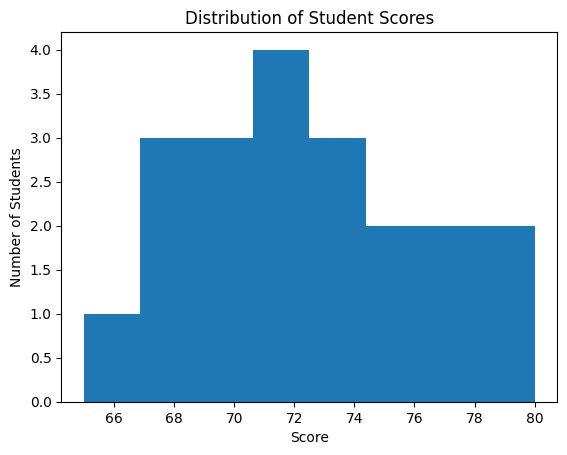

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["score"], bins=8)
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Scores")
plt.show()

H₀

H₀: μ = 70

মানে:

Population-এর true average score 70।

H₁

H₁: μ ≠ 70

মানে:

Population-এর true average score 70 নয়।

এখানে ≠ আছে, তাই এটা two-tailed।

**Average score কি 70?**

**তাহলে:**

**H₀: μ = 70**

**H₁: μ ≠ 70**

এটা হলো two-tailed one-sample test।

In [10]:
#hypothesis-testing code
from scipy import stats
t_stat, p_value = stats.ttest_1samp(df["score"],popmean=70)
print("t_statistic",t_stat)
print("p_value",p_value)

t_statistic 2.6332551201392915
p_value 0.016378412300820877


**ttest_1samp**

মানে:

One-sample t-test

আমরা একটা sample-এর mean-কে একটা known/hypothesized population mean-এর সাথে compare করছি।

In [11]:
#Decision
alpha =0.05

if p_value < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")



Reject H0


In [12]:
# more clear clarification
if p_value < 0.05:
    print("There is statistically significant evidence that the mean score differs from 70.")
else:
    print("There is not enough statistical evidence that the mean score differs from 70.")

There is statistically significant evidence that the mean score differs from 70.


**Confidence Interval**

In [14]:
confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(df["score"])-1,
    loc=df["score"].mean(),
    scale=stats.sem(df["score"])
)
print("95% Confidence Interval:", confidence_interval)

95% Confidence Interval: (np.float64(70.50263497103577), np.float64(74.39736502896423))


**p-value দিয়ে শুধু বোঝা যায় difference statistically significant কি না।**

**কিন্তু difference কতটা বড়/meaningful, সেটা বোঝার জন্য Effect Size।**

**Effect Size**

Statistically significant ≠ practically important


One-sample Cohen's d:

In [15]:
cohens_d = (mean_score - 70) / std_score
print("Cohen's d:", cohens_d)

Cohen's d: 0.588813745073083


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. Data
scores = [72, 68, 75, 71, 69, 80, 74, 77, 65, 73,
          70, 76, 68, 79, 71, 74, 67, 72, 78, 70]

df = pd.DataFrame({
    "score": scores
})

# 2. Inspect
print(df.head())
print(df.describe())

# 3. Mean
mean_score = df["score"].mean()
print("Mean:", mean_score)

# 4. Standard deviation
std_score = df["score"].std()
print("Std:", std_score)

# 5. Visualization
plt.hist(df["score"], bins=8)
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.title("Score Distribution")
plt.show()

# 6. One-sample t-test
t_stat, p_value = stats.ttest_1samp(
    df["score"],
    popmean=70
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

# 7. Decision
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to reject H0")

# 8. Confidence interval
ci = stats.t.interval(
    confidence=0.95,
    df=len(df) - 1,
    loc=mean_score,
    scale=stats.sem(df["score"]) #Standard Error (SE)
)

print("95% CI:", ci)

# 9. Cohen's d
cohens_d = (mean_score - 70) / std_score

print("Cohen's d:", cohens_d)